# Importing Lib's

In [ ]:
!pip install tensorflow

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
!unzip /content/myzipped-8-22-2025-2-53-43-pm.zip
!unzip /content/myzipped-8-22-2025-2-59-13-pm.zip

Archive:  /content/myzipped-8-22-2025-2-53-43-pm.zip
replace test/Benign/6300.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Archive:  /content/myzipped-8-22-2025-2-59-13-pm.zip
replace train/Benign/1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 


# Loading Data & Files

In [ ]:
base_directory = '/content/myzipped-8-22-2025-2-53-43-pm.zip' # test directory,
train_directory = os.path.join('/content/train')
test_directory = os.path.join('/content/test')

# Setting Data Generators for traning & testing data.

In [ ]:
image_size = (224, 224)
batch_size = 32

train_dataGen = ImageDataGenerator(
    rescale = 1 / 255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

test_dataGen = ImageDataGenerator(
    rescale = 1 / 255
)

# Check if directories and their contents exist
if not os.path.exists(train_directory):
    print(f"Error: Training directory not found at {train_directory}")
# elif not os.path.exists(test_directory): # Removed this check to ensure test_generator is always created
#     print(f"Error: Test directory not found at {test_directory}")
# else: # Removed this else block to ensure generators are always created
train_subdirs = [d for d in os.listdir(train_directory) if os.path.isdir(os.path.join(train_directory, d))] if os.path.exists(train_directory) else [] # Check only if train_directory exists
test_subdirs = [d for d in os.listdir(test_directory) if os.path.isdir(os.path.join(test_directory, d))] if os.path.exists(test_directory) else [] # Check only if test_directory exists


if not train_subdirs and os.path.exists(train_directory): # Added a condition to print error only if directory exists but no subdirs are found
    print(f"Error: No class subdirectories found in training directory: {train_directory}")
elif not test_subdirs and os.path.exists(test_directory): # Added a condition to print error only if directory exists but no subdirs are found
    print(f"Error: No class subdirectories found in test directory: {test_directory}")
else:
    print(f"Found subdirectories in training: {train_subdirs}")
    print(f"Found subdirectories in test: {test_subdirs}")

# Proceed with data generators(used to feed neural network).
train_generator = train_dataGen.flow_from_directory(
    train_directory,
    target_size= image_size,
    batch_size= batch_size,
    class_mode= 'binary'
)

test_generator = test_dataGen.flow_from_directory(
    test_directory,
    target_size= image_size,
    batch_size= batch_size,
    class_mode= 'binary'
)

print('Class Mapping: ', train_generator.class_indices)

# Plotting

In [ ]:
def plot_imgs(generator):
    imgs, labels = next(generator)
    plt.figure(figsize= (10, 5))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(imgs[i])
        plt.title('Cancer' if labels[i] == 1 else 'Non-Cancer')
        plt.axis('off')
    plt.show()

plot_imgs(train_generator)

# CNN Model.

In [ ]:
# Conv2D is used commonly for image data.
model = Sequential([
    Conv2D(32, (3, 3), activation= 'relu', input_shape= (224, 224, 3)), # 3 x 3 is kernal size.
    MaxPooling2D((2,2)),

    Conv2D(64, (3, 3), activation= 'relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation= 'relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(512, activation= 'relu'),
    Dense(1, activation= 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics= ['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor= 'val_loss',
    patience= 5,
    restore_best_weights= True,
    verbose = 1
)
# Use to adjust the learning_rate dynamically.
lr_schedular = ReduceLROnPlateau(
    monitor= 'val_loss',
    factor= 0.1,
    patience= 3,
    verbose= 1
)

In [33]:
history = model.fit(
    train_generator,
    epochs= 10,
    steps_per_epoch= train_generator.samples // batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.samples // batch_size, # Corrected validation_steps calculation
    callbacks = [early_stopping, lr_schedular]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.5030 - loss: 2.9715 - val_accuracy: 0.5052 - val_loss: 1.5197 - learning_rate: 0.0010
Epoch 2/10
1/6 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.4688 - loss: 0.9760

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4688 - loss: 0.9760 - val_accuracy: 0.5729 - val_loss: 0.6819 - learning_rate: 0.0010
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 81s 9s/step - accuracy: 0.6387 - loss: 0.6200 - val_accuracy: 0.6094 - val_loss: 0.7133 - learning_rate: 0.0010
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8125 - loss: 0.3821 - val_accuracy: 0.6042 - val_loss: 0.7363 - learning_rate: 0.0010
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7936 - loss: 0.4610
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
6/6 ━━━━━━━━━━━━━━━━━━━━ 82s 11s/step - accuracy: 0.7992 - loss: 0.4526 - val_accuracy: 0.5573 - val_loss: 1.0601 - learning_rate: 0.0010
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8750 - loss: 0.2787 - val_accuracy: 0.5417 - val_loss: 1.0953 - learning_rate: 1.0000e-04
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.8534 - loss: 0.2989 - val_accuracy: 0.5885 - val_loss: 0.9

# Plotting

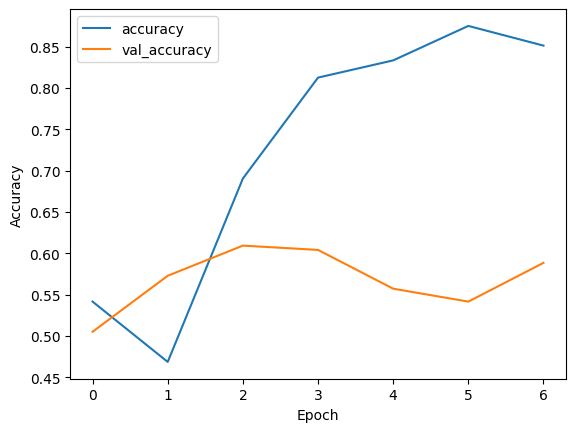

In [34]:
model.save('Skin_Cancer_CNN.h5')
plt.plot(history.history['accuracy'], label= 'accuracy')
plt.plot(history.history['val_accuracy'], label= 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Model Evaluation

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

test_pred = model.predict(test_generator)
test_pred_labels = (test_pred > 0.5).astype('int')
# It will contain the true labels of len of test_pred_labels.
test_true_labels = test_generator.classes[:len(test_pred_labels)]

print('Classification Report: ', classification_report(test_true_labels, test_pred_labels))
print('Confusion Matrix:', confusion_matrix(test_true_labels, test_pred_labels))

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 759ms/step
Classification Report:                precision    recall  f1-score   support

           0       0.48      0.82      0.61       100
           1       0.38      0.11      0.17       100

    accuracy                           0.47       200
   macro avg       0.43      0.46      0.39       200
weighted avg       0.43      0.47      0.39       200

Confusion Matrix: [[82 18]
 [89 11]]


In [ ]:
plt.figure(figsize= (10, 5))
sns.heatmap(confusion_matrix(test_true_labels, test_pred_labels), annot= True, fmt= 'd')
plt.xlabel('Predict')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Prediction Function

In [37]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

model = load_model('/content/Skin_Cancer_CNN.h5')

In [38]:
def predict_skin_cancer(image_path, model):
    img = image.load_img(image_path, target_size= (224, 224))
    img_array = image.img_to_array(img) # Convert to array.
    img_array = np.expand_dims(img_array, axis= 0) # Expand the dimension of array.

    prediction = model.predict(img_array)
    pred_class_label = 'Magligant' if prediction[0][0] > 0.5 else 'Benign'

    plt.imshow(img)
    plt.title(f'Predict: {pred_class_label}')
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


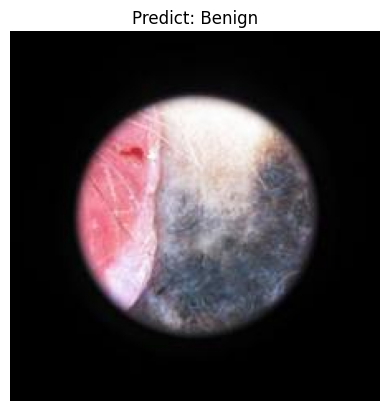

In [39]:
# Test1.
predict_skin_cancer('/content/test/Malignant/5617.jpg', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


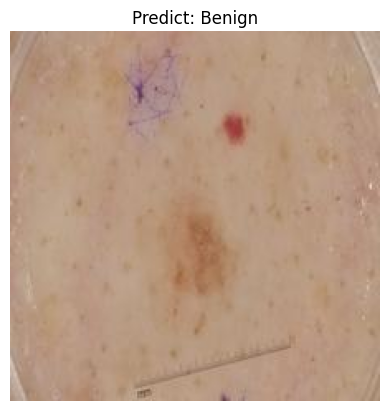

In [40]:
# Test2
predict_skin_cancer('/content/train/Malignant/1000.jpg', model)